# Test Visualization - Quick Data Insight

**One interesting question:** When the Bulls' top scorer has a big game (25+ points), do the Bulls win more?

This is a classic "star player impact" analysis that resonates with casual fans.


In [8]:
from nba_api.stats.static import teams
print(teams.get_teams()[0])

{'id': 1610612737, 'full_name': 'Atlanta Hawks', 'abbreviation': 'ATL', 'nickname': 'Hawks', 'city': 'Atlanta', 'state': 'Georgia', 'year_founded': 1949}


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguegamefinder, boxscoretraditionalv3

# Bulls setup
BULLS_ID = 1610612741
BULLS_RED = '#CE1141'
BULLS_BLACK = '#000000'

print("Setup complete!")


Setup complete!


In [10]:
# Get all Bulls regular season games
bulls_games = leaguegamefinder.LeagueGameFinder(
    team_id_nullable=BULLS_ID,
    season_nullable='2025-26',
    season_type_nullable='Regular Season'
).get_data_frames()[0]

print(f"Total games: {len(bulls_games)}")
print(f"Record: {len(bulls_games[bulls_games['WL'] == 'W'])}W - {len(bulls_games[bulls_games['WL'] == 'L'])}L")


Total games: 36
Record: 17W - 19L


In [11]:
# Pull player stats for each game (sampling last 15 games to save API calls)
game_ids = bulls_games['GAME_ID'].head(15).tolist()

all_player_games = []

for i, game_id in enumerate(game_ids):
    try:
        box = boxscoretraditionalv3.BoxScoreTraditionalV3(game_id=game_id)
        players = box.player_stats.get_data_frame()
        bulls_only = players[players['teamId'] == BULLS_ID].copy()
        bulls_only['game_id'] = game_id
        all_player_games.append(bulls_only)
        print(f"Fetched game {i+1}/{len(game_ids)}: {game_id}")
        time.sleep(0.6)  # Rate limiting
    except Exception as e:
        print(f"Error on {game_id}: {e}")

player_df = pd.concat(all_player_games, ignore_index=True)
print(f"\n✅ Collected {len(player_df)} player-game records")


Fetched game 1/15: 0022500503
Fetched game 2/15: 0022500489
Fetched game 3/15: 0022500480
Fetched game 4/15: 0022500466
Fetched game 5/15: 0022500452
Fetched game 6/15: 0022500437
Fetched game 7/15: 0022500427
Fetched game 8/15: 0022500411
Fetched game 9/15: 0022500396
Fetched game 10/15: 0022500384
Fetched game 11/15: 0022500367
Fetched game 12/15: 0022501223
Fetched game 13/15: 0022501209
Fetched game 14/15: 0022500361
Fetched game 15/15: 0022500345

✅ Collected 194 player-game records


In [12]:
# Find the top scorer
player_df['fullName'] = player_df['firstName'] + ' ' + player_df['familyName']

# Get average points per player
avg_points = player_df.groupby('fullName')['points'].agg(['mean', 'count']).sort_values('mean', ascending=False)
avg_points = avg_points[avg_points['count'] >= 5]  # Played at least 5 games
print("Top scorers (avg PPG):")
print(avg_points.head(5).round(1))

# Pick the top scorer
top_scorer = avg_points.index[0]
print(f"\n⭐ Analyzing: {top_scorer}")


Top scorers (avg PPG):
                mean  count
fullName                   
Matas Buzelis   16.3     15
Nikola Vučević  16.2     15
Josh Giddey     16.2     11
Coby White      15.9     12
Kevin Huerter   11.7     12

⭐ Analyzing: Matas Buzelis


In [13]:
# Get that player's scoring and merge with game results
star_games = player_df[player_df['fullName'] == top_scorer][['game_id', 'points']].copy()
star_games = star_games.merge(bulls_games[['GAME_ID', 'WL', 'MATCHUP', 'GAME_DATE']], 
                               left_on='game_id', right_on='GAME_ID')

# Categorize: 25+ points vs under 25
star_games['big_game'] = star_games['points'] >= 25

# Win rate when scoring 25+ vs under 25
big_game_stats = star_games.groupby('big_game')['WL'].apply(
    lambda x: (x == 'W').sum() / len(x) * 100
).round(1)

print(f"\n🔥 {top_scorer} Impact Analysis:")
print(f"   Win % when scoring 25+ pts: {big_game_stats.get(True, 0)}%")
print(f"   Win % when scoring <25 pts: {big_game_stats.get(False, 0)}%")
print(f"\n   Games with 25+: {star_games['big_game'].sum()}")
print(f"   Games under 25: {(~star_games['big_game']).sum()}")



🔥 Matas Buzelis Impact Analysis:
   Win % when scoring 25+ pts: 50.0%
   Win % when scoring <25 pts: 53.8%

   Games with 25+: 2
   Games under 25: 13


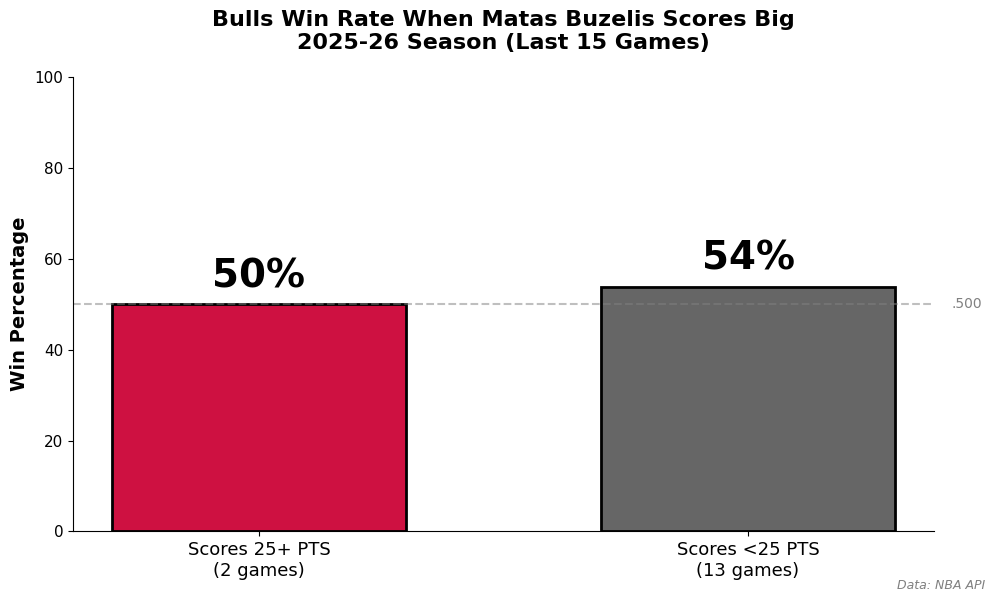


✅ Saved to output/test_star_impact.png


In [ ]:
# Create the visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
games_25plus = int(star_games['big_game'].sum())
games_under25 = int((~star_games['big_game']).sum())
categories = [f'Scores 25+ PTS\n({games_25plus} games)', 
              f'Scores <25 PTS\n({games_under25} games)']
win_rates = [big_game_stats.get(True, 0), big_game_stats.get(False, 0)]
colors = [BULLS_RED, '#666666']

# Bar chart
bars = ax.bar(categories, win_rates, color=colors, edgecolor='black', linewidth=2, width=0.6)

# Add value labels on bars
for bar, rate in zip(bars, win_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{rate:.0f}%', ha='center', va='bottom', 
            fontsize=28, fontweight='bold', color=BULLS_BLACK)

# Styling
ax.set_ylim(0, 100)
ax.set_ylabel('Win Percentage', fontsize=14, fontweight='bold')
ax.set_title(f'Bulls Win Rate When {top_scorer} Scores Big\n2025-26 Season (Last 15 Games)', 
             fontsize=16, fontweight='bold', pad=20)

# Add .500 reference line
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(1.02, 50, '.500', transform=ax.get_yaxis_transform(), 
        va='center', fontsize=10, color='gray')

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=11)

# Add footer
fig.text(0.99, 0.01, 'Data: NBA API', ha='right', fontsize=9, 
         style='italic', color='gray')

plt.tight_layout()
plt.savefig('output/test_star_impact.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Saved to output/test_star_impact.png")


## 📊 The Insight

This visualization tests a compelling "star player impact" question:

**Do the Bulls win more when their top scorer has a big game?**

Why this works for Instagram:
- Simple, relatable question any fan would wonder
- Clear visual contrast (Bulls red vs gray)
- Concrete numbers that tell a story
- Works as a single-image post

---

*Delete this notebook when done - just a test!*
